In [389]:
# Basic imports 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
###pytorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics



In [390]:
#od.download("https://www.kaggle.com/datasets/farazrahman/earthquake")

In [391]:
data = pd.read_csv("earthquake/all_month.csv", delimiter=",")
data.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-07-07T01:47:30.830Z,38.763168,-122.724335,1.7000,0.77,md,6.0,120.0,0.001626,0.02,...,2026-07-07T01:49:07.537Z,"3 km WSW of Anderson Springs, CA",earthquake,0.73,1.070000,0.180000,7.0,automatic,nc,nc
1,2026-07-07T01:46:33.572Z,31.637000,-104.441000,2.9078,1.00,ml,13.0,183.0,0.000000,0.50,...,2026-07-07T01:51:52.544Z,"60 km S of Whites City, New Mexico",earthquake,0.00,1.708419,0.200000,10.0,automatic,tx,tx
2,2026-07-07T01:26:45.608Z,-57.365400,-66.625900,10.0000,5.90,mww,82.0,82.0,4.831000,1.03,...,2026-07-07T01:58:54.415Z,Drake Passage,earthquake,8.68,1.845000,0.080000,15.0,reviewed,us,us
3,2026-07-07T01:13:23.990Z,38.542667,-122.374832,3.9200,2.44,md,5.0,221.0,0.350600,0.08,...,2026-07-07T01:42:23.137Z,"7 km ESE of Angwin, CA",earthquake,8.46,4.440000,NaN,1.0,automatic,nc,nc
4,2026-07-07T01:06:47.170Z,33.339833,-116.392833,6.1900,0.87,ml,46.0,31.0,0.025170,0.22,...,2026-07-07T01:10:16.415Z,"9 km N of Borrego Springs, CA",earthquake,0.19,0.460000,0.181971,20.0,automatic,ci,ci


In [392]:
columns = data.columns
columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')

In [393]:
relevant_col = columns[1: 5]
data = data [relevant_col]
data

,latitude,longitude,depth,mag
0,38.763168,-122.724335,1.7000,0.77
1,31.637000,-104.441000,2.9078,1.00
2,-57.365400,-66.625900,10.0000,5.90
3,38.542667,-122.374832,3.9200,2.44
4,33.339833,-116.392833,6.1900,0.87
...,...,...,...,...
10644,56.019000,-159.691000,14.0000,1.50
10645,12.780500,-90.258500,10.0000,4.40
10646,-36.263400,177.686400,228.4190,4.00
10647,18.536833,-67.278000,23.5200,2.74


In [394]:
bins = [-2, 3.9, 5.9, 9.9 ]
labels = ["minor", "moderate", "major" ]
data["magnitude_class"] = pd.cut(data["mag"], bins=bins, labels=labels )
mag_class_counts = data["magnitude_class"].value_counts()
mag_class_counts

magnitude_class
minor       9547
moderate    1078
major         21
Name: count, dtype: int64

In [395]:
data.describe()

,latitude,longitude,depth,mag
count,10649.000000,10649.000000,10649.000000,10646.000000
mean,39.350394,-108.406358,21.644089,1.668053
std,17.914352,78.514589,49.305527,1.284950
min,-62.112500,-179.951000,-3.170000,-1.340000
25%,33.313333,-153.033000,3.570000,0.800000
50%,38.824501,-122.764999,7.870000,1.420000
75%,52.811000,-112.220000,16.500000,2.100000
max,78.412500,179.999100,685.692000,7.800000


In [396]:
data.duplicated().sum()
#No duplicates are 

np.int64(0)

In [397]:
data.isnull().sum()

latitude           0
longitude          0
depth              0
mag                3
magnitude_class    3
dtype: int64

In [398]:
data[data["magnitude_class"].isnull()]

,latitude,longitude,depth,mag,magnitude_class
529,31.612000,-104.178000,0.00,NaN,NaN
3453,39.387833,-123.235667,8.09,NaN,NaN
5264,51.651700,176.017200,35.00,NaN,NaN


In [399]:
data = data.dropna(axis=0)

In [400]:
data[data["magnitude_class"].isnull()]
data.isnull().sum()

latitude           0
longitude          0
depth              0
mag                0
magnitude_class    0
dtype: int64

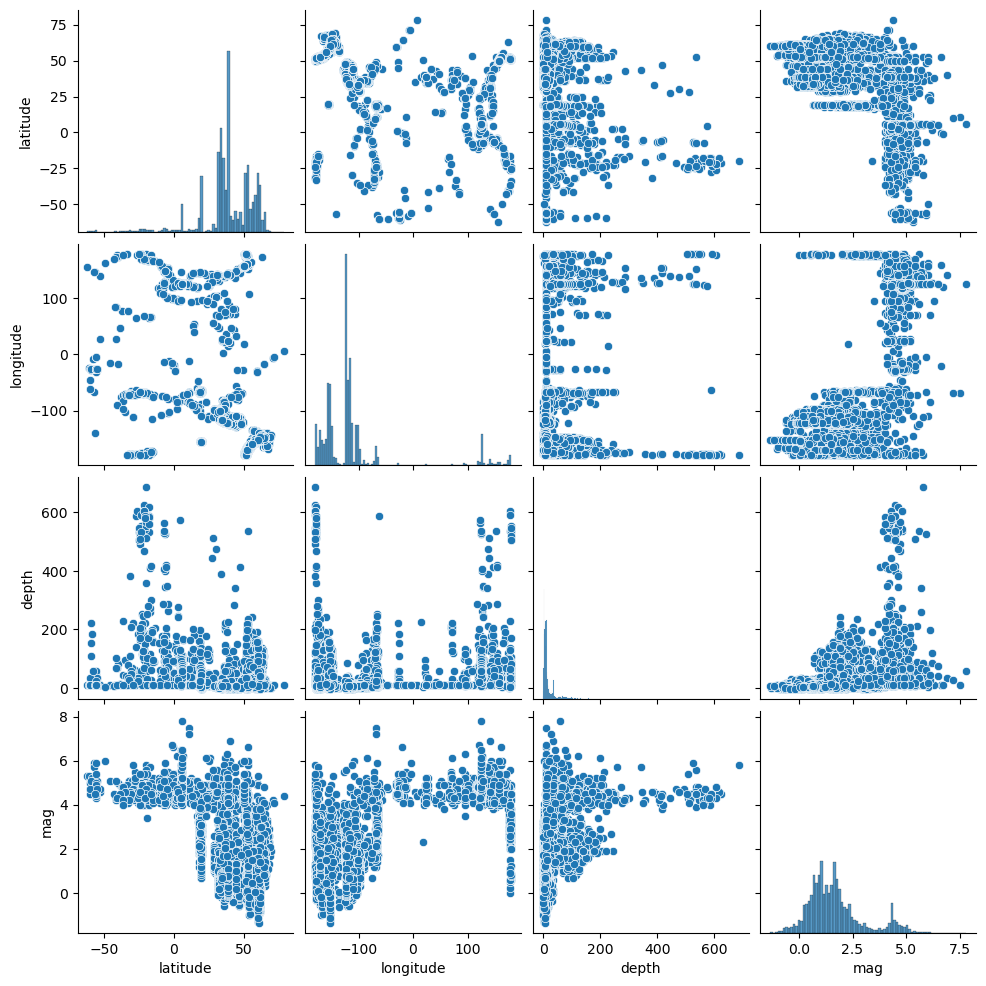

In [401]:
### Visualization
sns.pairplot(data)


<Axes: >

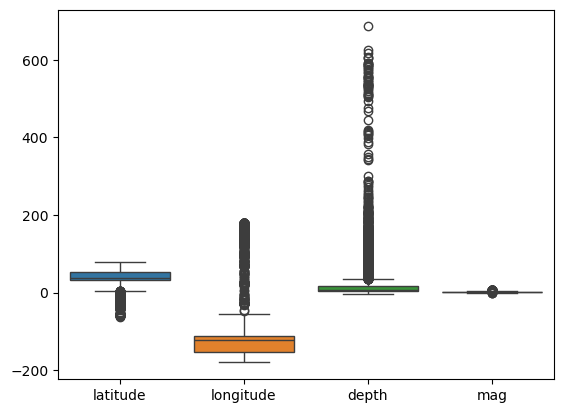

In [402]:
sns.boxplot(data)


In [403]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [404]:
mapping = {"minor": 0 ,
           "moderate": 1, 
           "major": 2}
data["mag_class"] = data["magnitude_class"].map(mapping)

C:\Users\Global Lecturer\AppData\Local\Temp\ipykernel_13040\3540413620.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["mag_class"] = data["magnitude_class"].map(mapping)


In [405]:
data = data.drop("magnitude_class", axis=1)


In [406]:
data

,latitude,longitude,depth,mag,mag_class
0,38.763168,-122.724335,1.7000,0.77,0
1,31.637000,-104.441000,2.9078,1.00,0
2,-57.365400,-66.625900,10.0000,5.90,1
3,38.542667,-122.374832,3.9200,2.44,0
4,33.339833,-116.392833,6.1900,0.87,0
...,...,...,...,...,...
10644,56.019000,-159.691000,14.0000,1.50,0
10645,12.780500,-90.258500,10.0000,4.40,1
10646,-36.263400,177.686400,228.4190,4.00,1
10647,18.536833,-67.278000,23.5200,2.74,0


In [407]:
label = data["mag_class"]
features = data.drop("mag_class", axis=1)



In [408]:
#### Convert to pytorch tensors

In [409]:
features

,latitude,longitude,depth,mag
0,38.763168,-122.724335,1.7000,0.77
1,31.637000,-104.441000,2.9078,1.00
2,-57.365400,-66.625900,10.0000,5.90
3,38.542667,-122.374832,3.9200,2.44
4,33.339833,-116.392833,6.1900,0.87
...,...,...,...,...
10644,56.019000,-159.691000,14.0000,1.50
10645,12.780500,-90.258500,10.0000,4.40
10646,-36.263400,177.686400,228.4190,4.00
10647,18.536833,-67.278000,23.5200,2.74


In [410]:
x_train, x_test, y_train, y_test = train_test_split(features.values, label.values, test_size=0.3, random_state=42 )

In [411]:
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

In [412]:
x_train_T = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_T = torch.tensor(y_train, dtype=torch.long)
x_test_T = torch.tensor(x_test, dtype = torch.float32)
y_test_T = torch.tensor(y_test, dtype=torch.long) 

print(np.isnan(y_train_T).sum())

print(y_test_T[:10])

tensor(0)
tensor([0, 1, 1, 1, 0, 0, 0, 0, 0, 1])


C:\Users\Global Lecturer\AppData\Local\Temp\ipykernel_13040\1196436615.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(np.isnan(y_train_T).sum())


In [413]:
train_data = TensorDataset(x_train_T, y_train_T)
test_data = TensorDataset(x_test_T, y_test_T)

train_loader = DataLoader(dataset=train_data, batch_size=32, shuffle=True )
test_loader = DataLoader(dataset = test_data, batch_size=32)



In [414]:
x, y = next(iter(train_loader))
x.shape, y.shape



(torch.Size([32, 4]), torch.Size([32]))

In [415]:
class EarthquakeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=4, out_features=6),
            #nn.BatchNorm1d(6),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(in_features=6, out_features=6),
           # nn.BatchNorm1d(6),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(in_features=8, out_features=3),
        
        )
    def forward(self, x):
        return self.network(x)

In [416]:
def evaluate_model(model, dataloader, lossfunc, metrics):
    
    metrics.reset()
    model.eval()
    total_loss = 0.0
    with torch.inference_mode():
        for x, y in dataloader:
            logits = model(x)
            y_pred = torch.argmax(logits, dim=1) 
            loss = lossfunc(logits, y)
            total_loss += loss.item()
            metrics.update(y_pred, y)
        total_loss /= len(dataloader)
        return metrics.compute().item(), total_loss 
    
    
def train_model(model, train_loader, test_loader, train_metrics, test_metrics,optimizer, loss_func, epochs):
    
    history = {
        "epoch": [],
        "train_loss" : [],
        "test_loss" : [],
        "train_acc": [],
        "test_acc": [] 
        }

    for epoch in range(epochs):
        train_metrics.reset()
        model.train()
        total_loss = 0.0
        
        for x, y in train_loader:
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_func(logits, y)
            total_loss += loss.item()
            y_pred = torch.argmax(logits, dim=1)
            loss.backward()
            optimizer.step()
            train_metrics.update(y_pred, y)
        total_loss /= len(train_loader)
            
        test_acc, test_loss = evaluate_model(
                        model=model, dataloader=test_loader, 
                        lossfunc=loss_func, metrics=test_metrics, 
                        )
        history["epoch"].append(epoch)
        history["train_loss"].append(total_loss)
        history["train_acc"].append(train_metrics.compute().item())
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        
        print(
            f"{epoch+1}/{epochs}," 
            f"train loss: {history['train_loss'][-1]:.3f},"
            f"train acc: {history['train_acc'][-1]:.3f},"
            f"test loss: {history['test_loss'][-1]:.3f},"
            f"test acc: {history['test_acc'][-1]:.3f}"
              )
    return history
    
            
    


In [417]:
import torchmetrics
from torchmetrics.classification import MulticlassAccuracy

In [418]:
torch.manual_seed(42)
net = EarthquakeNet()

In [419]:
optimizer = torch.optim.Adam(params=net.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
train_metrics = MulticlassAccuracy(num_classes=3)
test_metrics = MulticlassAccuracy(num_classes=3)

In [420]:
model_history = train_model(
    model=net, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    train_metrics=train_metrics, 
    test_metrics= test_metrics,
    optimizer=optimizer,
    loss_func=loss_func,
    epochs=100)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x6 and 8x3)